# CVRP Walkthrough

The **Capacitated Vehicle Routing Problem** is TSP's first real generalisation:

- A fleet of $K$ vehicles instead of one.
- Each vehicle has a **capacity** $Q_k$.
- Each customer $i$ has a **demand** $q_i$.
- All vehicles start and end at a shared depot.
- Each customer is visited exactly once, by exactly one vehicle.
- For each vehicle, $\sum_{i \in \text{route}_k} q_i \le Q_k$.
- Objective: minimise total distance across all routes.

## What's new in the OR-Tools API

Two new concepts on top of TSP:

1. **Multiple vehicles** — `RoutingIndexManager(n, num_vehicles, depot)` with `num_vehicles > 1`. The model now has $K$ start/end pairs.
2. **Dimensions** — a *dimension* tracks a quantity that accumulates along a route. The capacity dimension's cumul = sum of demands visited so far. The same machinery later powers time windows, distance limits, working hours, anything that needs to be "summed and bounded."

In [1]:
%load_ext autoreload
%autoreload 2

import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

from vrp_lib import euclidean_distance_matrix

random.seed(11)
np.random.seed(11)

## 1. An instance with demands

20 customers around a central depot. Demands are random integers in `[1, 10]`. We plot marker size proportional to demand.

In [2]:
N_CUSTOMERS = 20
DEPOT = 0
SCALE = 100

points = [(50.0, 50.0)] + [
    (random.uniform(0, 100), random.uniform(0, 100)) for _ in range(N_CUSTOMERS)
]
demands = [0] + [random.randint(1, 10) for _ in range(N_CUSTOMERS)]
matrix = euclidean_distance_matrix(points, scale=SCALE)

total_demand = sum(demands)
print(f"{N_CUSTOMERS} customers, total demand = {total_demand}")
print(f"Demands: {demands[1:]}")

20 customers, total demand = 88
Demands: [6, 4, 9, 5, 1, 2, 10, 2, 7, 2, 5, 7, 2, 1, 1, 4, 4, 1, 8, 7]


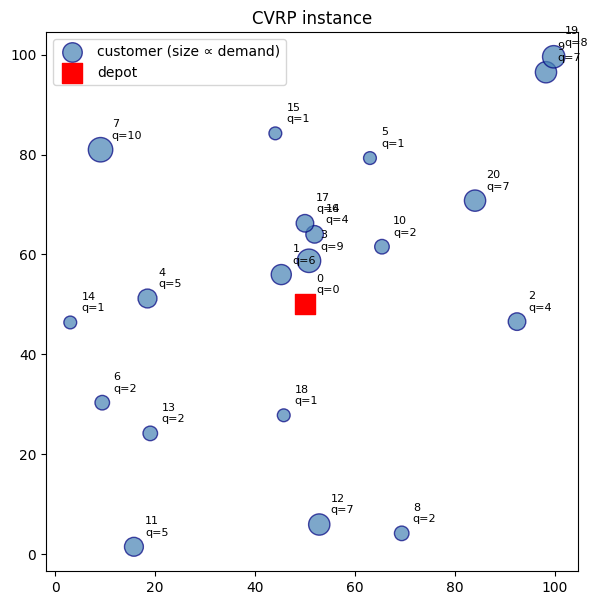

In [3]:
def plot_instance(points, demands, title="CVRP instance"):
    fig, ax = plt.subplots(figsize=(7, 7))
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    sizes = [60 + d * 25 for d in demands]
    ax.scatter(xs[1:], ys[1:], s=sizes[1:], c="steelblue", alpha=0.7,
               edgecolors="navy", label="customer (size \u221d demand)")
    ax.scatter(*points[0], c="red", s=200, marker="s", zorder=5, label="depot")
    for i, (x, y) in enumerate(points):
        ax.annotate(f"{i}\nq={demands[i]}", (x, y),
                    textcoords="offset points", xytext=(8, 8), fontsize=8)
    ax.set_aspect("equal"); ax.legend(); ax.set_title(title)
    plt.show()

plot_instance(points, demands)

## 2. Building the CVRP model

Five pieces, three of which are TSP-identical:

1. `RoutingIndexManager(n, K, depot)` with $K$ vehicles.
2. `RoutingModel(manager)`.
3. **Distance callback + arc cost** — same as TSP.
4. **Demand callback** — for each node, how much demand does the vehicle pick up there? Registered with `RegisterUnaryTransitCallback` (it takes only one argument, the from-index).
5. **Capacity dimension** — `AddDimensionWithVehicleCapacity(demand_idx, slack, capacities, start_at_zero, name)` ties the demand callback to per-vehicle limits.

In [4]:
import math


def build_cvrp_model(matrix, demands, num_vehicles, capacities, depot=0):
    n = len(matrix)
    manager = pywrapcp.RoutingIndexManager(n, num_vehicles, depot)
    routing = pywrapcp.RoutingModel(manager)

    def distance_cb(fi, ti):
        return matrix[manager.IndexToNode(fi)][manager.IndexToNode(ti)]
    transit_idx = routing.RegisterTransitCallback(distance_cb)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_idx)

    def demand_cb(fi):
        return demands[manager.IndexToNode(fi)]
    demand_idx = routing.RegisterUnaryTransitCallback(demand_cb)

    routing.AddDimensionWithVehicleCapacity(
        demand_idx,
        0,            # slack: extra capacity we allow on top (0 = hard limit)
        capacities,   # per-vehicle capacity
        True,         # start cumul to zero at the depot
        "Capacity",
    )
    return manager, routing


def solve_model(routing, time_limit=5):
    params = pywrapcp.DefaultRoutingSearchParameters()
    params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    params.time_limit.FromSeconds(time_limit)
    return routing.SolveWithParameters(params)


def extract_routes(manager, routing, solution, demands):
    routes, loads = [], []
    for v in range(routing.vehicles()):
        idx = routing.Start(v)
        route, load = [], 0
        while not routing.IsEnd(idx):
            node = manager.IndexToNode(idx)
            route.append(node)
            load += demands[node]
            idx = solution.Value(routing.NextVar(idx))
        route.append(manager.IndexToNode(idx))
        routes.append(route)
        loads.append(load)
    return routes, loads


def print_routes(routes, loads, capacities, total_demand):
    used = sum(1 for ld in loads if ld > 0)
    min_required = math.ceil(total_demand / max(capacities))
    print(f"Vehicles used: {used} / {len(routes)}  (minimum required: {min_required})")
    for v, (r, ld) in enumerate(zip(routes, loads)):
        cap = capacities[v]
        if ld == 0:
            print(f"  vehicle {v}:  --- unused ---")
        else:
            pct = 100 * ld / cap
            print(f"  vehicle {v}:  load {ld:>2d}/{cap} ({pct:>3.0f}%)   {' -> '.join(map(str, r))}")


NUM_VEHICLES = 4
CAPACITY = 40
manager, routing = build_cvrp_model(matrix, demands, NUM_VEHICLES, [CAPACITY] * NUM_VEHICLES)
solution = solve_model(routing, time_limit=5)

print(f"Status: {routing.status()}   Objective: {solution.ObjectiveValue()}")
routes, loads = extract_routes(manager, routing, solution, demands)
print_routes(routes, loads, [CAPACITY] * NUM_VEHICLES, total_demand)

Status: 1   Objective: 48441
Vehicles used: 3 / 4  (minimum required: 3)
  vehicle 0:  --- unused ---
  vehicle 1:  load 40/40 (100%)   0 -> 17 -> 15 -> 7 -> 4 -> 14 -> 6 -> 13 -> 11 -> 12 -> 8 -> 18 -> 0
  vehicle 2:  load 39/40 ( 98%)   0 -> 1 -> 16 -> 5 -> 19 -> 9 -> 20 -> 2 -> 10 -> 0
  vehicle 3:  load  9/40 ( 22%)   0 -> 3 -> 0


### Why isn't the load balanced?

The output above is a little surprising at first glance — we asked for 4 vehicles, the solver only used 3 of them, and the third one carries just a single customer. That's *not* a bug or a suboptimal heuristic; it falls out of how the problem is defined:

- **The CVRP objective is total distance**, not load balance, not vehicle utilisation, not driver fairness. The solver picks the cheapest feasible assignment, full stop.
- **`NUM_VEHICLES` is an upper bound**, not a target. The model has $K$ vehicles available; it uses however many minimise distance. An unused vehicle just sits at the depot (`0 -> 0`).
- **The mathematical floor** on vehicles used is $\lceil \text{total demand} / \text{capacity} \rceil = \lceil 88 / 40 \rceil = 3$. So we *must* use at least 3 vehicles, and the solver does — vehicle 0 stays idle.
- **Among the 3 used, two fill up and the third carries the remainder.** Here vehicle 3 visits only node 3 (demand 9) because node 3 is positioned such that a dedicated round trip is cheaper than detouring an existing route to include it. Forcing a balanced split (~30+30+28) is possible but typically *raises* total distance — routes start crossing each other.

> If load balance is actually a business requirement ("every driver finishes at roughly the same time"), use `routing.SetGlobalSpanCostCoefficient(coef)` to penalise the longest route per vehicle. That's a future exploration.

## 3. Visualise multi-vehicle routes

One colour per vehicle. Unused vehicles (just `depot -> depot`) are skipped.

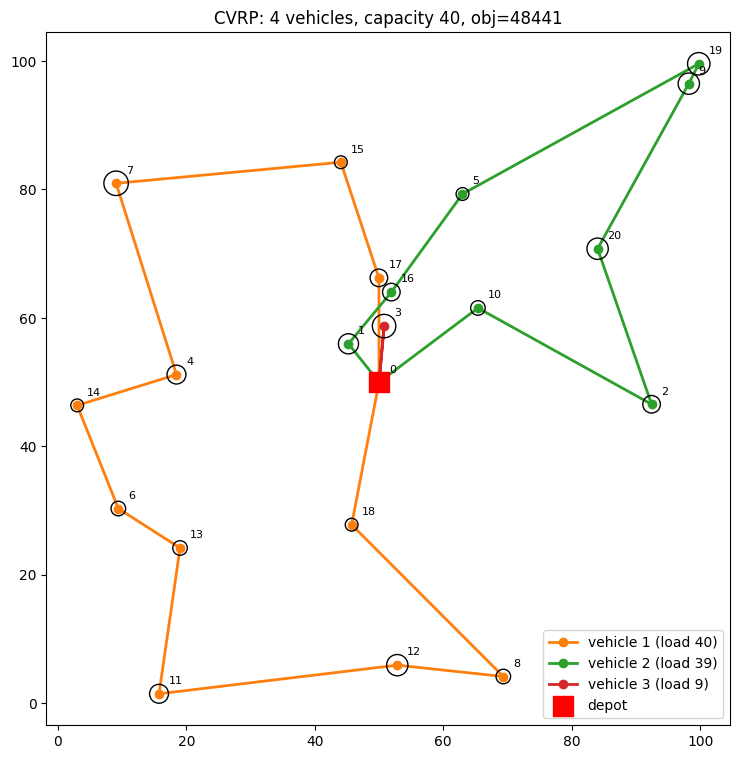

In [5]:
def plot_cvrp(points, routes, demands, title=""):
    fig, ax = plt.subplots(figsize=(9, 9))
    colors = plt.cm.tab10(np.linspace(0, 1, max(10, len(routes))))
    for v, route in enumerate(routes):
        if len(route) <= 2:
            continue
        rx = [points[i][0] for i in route]
        ry = [points[i][1] for i in route]
        ax.plot(rx, ry, "-o", color=colors[v], linewidth=2,
                label=f"vehicle {v} (load {sum(demands[i] for i in route)})")
    sizes = [60 + d * 25 for d in demands]
    xs = [p[0] for p in points]; ys = [p[1] for p in points]
    ax.scatter(xs[1:], ys[1:], s=sizes[1:], facecolors="none", edgecolors="black", zorder=3)
    ax.scatter(*points[0], c="red", s=200, marker="s", zorder=5, label="depot")
    for i, (x, y) in enumerate(points):
        ax.annotate(str(i), (x, y), textcoords="offset points", xytext=(7, 7), fontsize=8)
    ax.set_aspect("equal"); ax.legend(loc="lower right"); ax.set_title(title)
    plt.show()

plot_cvrp(points, routes, demands,
          title=f"CVRP: 4 vehicles, capacity {CAPACITY}, obj={solution.ObjectiveValue()}")

## 4. Capacity sensitivity

What's the relationship between fleet capacity and total distance? Intuitively:

- **Tight capacity** → many short routes → high total distance (lots of trips back to depot).
- **Loose capacity** → few long routes → low total distance, but each driver works harder.

We sweep capacity, hold the fleet size at 6 (plenty of vehicles), and count how many actually get used.

In [6]:
def solve_cvrp_inline(matrix, demands, num_vehicles, capacities, time_limit=3):
    manager, routing = build_cvrp_model(matrix, demands, num_vehicles, capacities)
    sol = solve_model(routing, time_limit=time_limit)
    if sol is None:
        return None
    routes, loads = extract_routes(manager, routing, sol, demands)
    return {"obj": sol.ObjectiveValue(), "routes": routes, "loads": loads}


rows = []
for cap in [25, 30, 40, 60, 100, 200]:
    r = solve_cvrp_inline(matrix, demands, num_vehicles=6, capacities=[cap] * 6)
    if r is None:
        rows.append({"capacity": cap, "objective": None, "vehicles_used": None})
        continue
    used = sum(1 for ld in r["loads"] if ld > 0)
    rows.append({"capacity": cap, "objective": r["obj"], "vehicles_used": used})

cap_df = pd.DataFrame(rows)
cap_df

,capacity,objective,vehicles_used
0,25,57361,4
1,30,54332,3
2,40,48441,3
3,60,46541,2
4,100,43307,1
5,200,43307,1


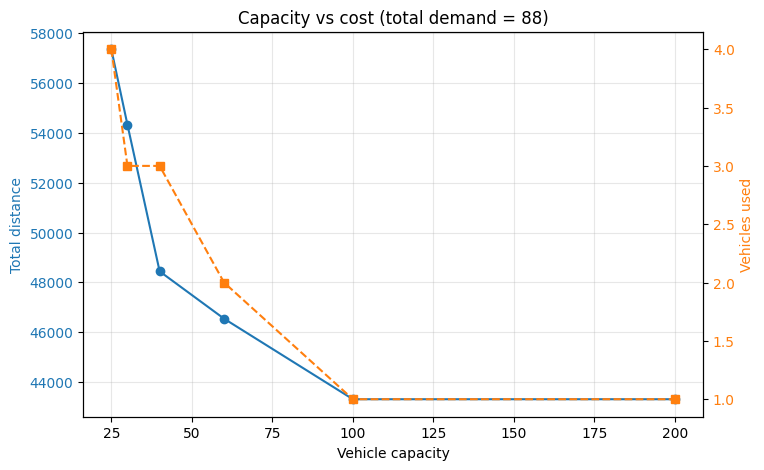

In [7]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ok = cap_df.dropna()
color1, color2 = "tab:blue", "tab:orange"
ax1.plot(ok["capacity"], ok["objective"], "o-", color=color1)
ax1.set_xlabel("Vehicle capacity")
ax1.set_ylabel("Total distance", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ok["capacity"], ok["vehicles_used"], "s--", color=color2)
ax2.set_ylabel("Vehicles used", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)

plt.title(f"Capacity vs cost (total demand = {total_demand})")
plt.show()

## 5. Dropping nodes (disjunctions)

What if the problem is *infeasible* — too few vehicles or too tight a capacity? The default CVRP model just returns no solution. Often what you actually want is: *serve as many customers as possible; if you have to skip some, prefer the ones whose penalty is small.*

OR-Tools models this with **disjunctions**. `routing.AddDisjunction([node_idx], penalty)` says "either visit this node or pay this penalty." Picking the penalty:

- Too low → the solver drops everything (cheaper than serving anyone).
- Too high → effectively unchanged from the strict version.
- Just right → the solver drops only the customers it really can't fit.

In [8]:
def solve_cvrp_with_drops(matrix, demands, num_vehicles, capacities, drop_penalty, time_limit=3):
    manager, routing = build_cvrp_model(matrix, demands, num_vehicles, capacities)
    n = len(matrix)
    for node in range(n):
        if node == DEPOT:
            continue
        routing.AddDisjunction([manager.NodeToIndex(node)], drop_penalty)
    sol = solve_model(routing, time_limit=time_limit)
    if sol is None:
        return None
    routes, loads = extract_routes(manager, routing, sol, demands)
    visited = {node for r in routes for node in r}
    dropped = sorted(i for i in range(n) if i not in visited)
    return {"obj": sol.ObjectiveValue(), "routes": routes, "loads": loads, "dropped": dropped}


# Make it tight on purpose: 2 vehicles, 30 capacity each = 60 total, total demand 88.
scarce = solve_cvrp_with_drops(matrix, demands,
                               num_vehicles=2, capacities=[30, 30],
                               drop_penalty=5000)

served_demand = sum(demands[i] for r in scarce["routes"] for i in r if i != DEPOT)
print(f"Objective (incl. drop penalties): {scarce['obj']}")
print(f"Demand served: {served_demand} / {total_demand}")
print(f"Dropped {len(scarce['dropped'])} nodes: {scarce['dropped']}")
for v, (r, ld) in enumerate(zip(scarce["routes"], scarce["loads"])):
    print(f"  vehicle {v}: load={ld}/30  {' -> '.join(map(str, r))}")

Objective (incl. drop penalties): 55396
Demand served: 57 / 88
Dropped 5 nodes: [2, 7, 8, 9, 19]
  vehicle 0: load=28/30  0 -> 10 -> 20 -> 5 -> 15 -> 17 -> 16 -> 3 -> 0
  vehicle 1: load=29/30  0 -> 18 -> 12 -> 11 -> 13 -> 6 -> 14 -> 4 -> 1 -> 0


In [9]:
rows = []
for penalty in [100, 500, 1000, 2000, 5000, 20000]:
    r = solve_cvrp_with_drops(matrix, demands,
                              num_vehicles=2, capacities=[30, 30],
                              drop_penalty=penalty, time_limit=2)
    served = sum(
        demands[i] for route in r["routes"] for i in route if i != DEPOT
    )
    rows.append({
        "drop_penalty": penalty,
        "objective": r["obj"],
        "dropped": len(r["dropped"]),
        "served_demand": served,
    })
pd.DataFrame(rows)

,drop_penalty,objective,dropped,served_demand
0,100,2000,20,0
1,500,10000,20,0
2,1000,19607,16,23
3,2000,35607,16,23
4,5000,55589,4,58
5,20000,115589,4,58


## 6. Heterogeneous fleet

Real fleets aren't uniform — you might have one large truck and several small vans, each with different capacity. Since `AddDimensionWithVehicleCapacity` already accepts a per-vehicle capacity *list*, this is essentially free.

Objective: 49051
Vehicles used: 3 / 5  (minimum required: 2)
  vehicle 0:  load 57/60 ( 95%)   0 -> 3 -> 16 -> 17 -> 7 -> 15 -> 5 -> 19 -> 9 -> 20 -> 2 -> 10 -> 0
  vehicle 1:  load 25/25 (100%)   0 -> 4 -> 14 -> 6 -> 13 -> 11 -> 12 -> 8 -> 18 -> 0
  vehicle 2:  load  6/25 ( 24%)   0 -> 1 -> 0
  vehicle 3:  --- unused ---
  vehicle 4:  --- unused ---


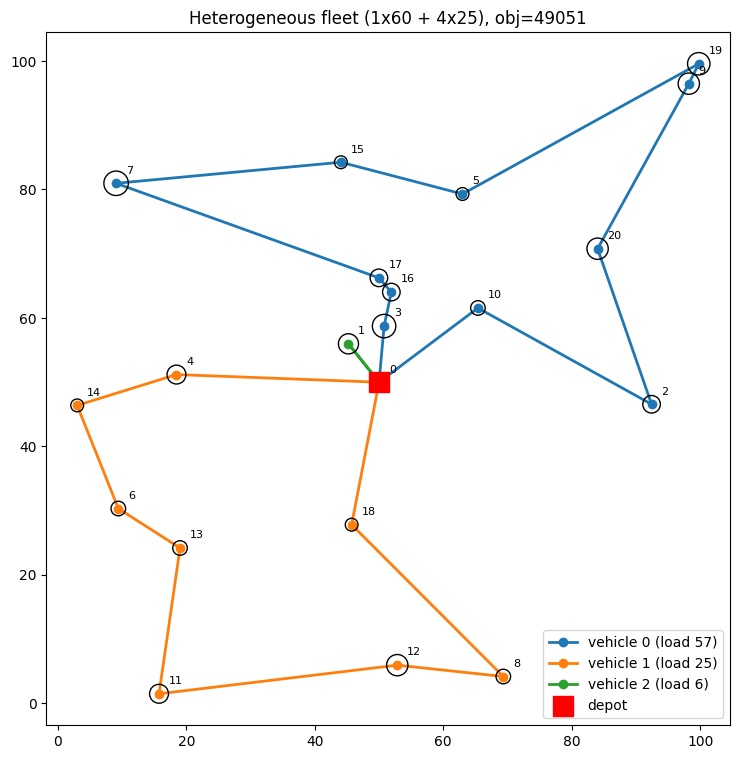

In [10]:
# Same over-allocation pattern as §2 — solver uses only what minimises distance.
het_capacities = [60, 25, 25, 25, 25]   # one large + four small
het = solve_cvrp_inline(matrix, demands, num_vehicles=5, capacities=het_capacities, time_limit=5)

print(f"Objective: {het['obj']}")
print_routes(het["routes"], het["loads"], het_capacities, total_demand)

plot_cvrp(points, het["routes"], demands,
          title=f"Heterogeneous fleet (1x60 + 4x25), obj={het['obj']}")

## Where to go next

The capacity dimension is the template. You'll meet at least three close relatives:

- **VRPTW (time windows)** — register a time-transit callback (`distance / speed + service time`), add a `Time` dimension with per-node `[a_i, b_i]` window via `CumulVar(idx).SetRange(a, b)`.
- **Distance/working-hours limit** — same shape, but the dimension is *distance* or *time worked* rather than load.
- **Multi-depot** — `RoutingIndexManager(n, K, starts, ends)` lets each vehicle have its own start/end node.

## Promoted to `vrp_lib`

The inline `build_cvrp_model` / `solve_cvrp_inline` / `solve_cvrp_with_drops` functions are now packaged as `vrp_lib.solve_cvrp`, with the disjunction logic gated behind a `drop_node_penalty` argument. Future notebooks can do:

```python
from vrp_lib import solve_cvrp

result = solve_cvrp(matrix, demands, vehicle_capacities=[40]*4, time_limit_seconds=5)
# result.routes, result.loads, result.dropped, result.total_distance
```

Backed by `tests/test_cvrp.py` so accidental regressions show up immediately.